### Exercise3.1 ~ 3.5

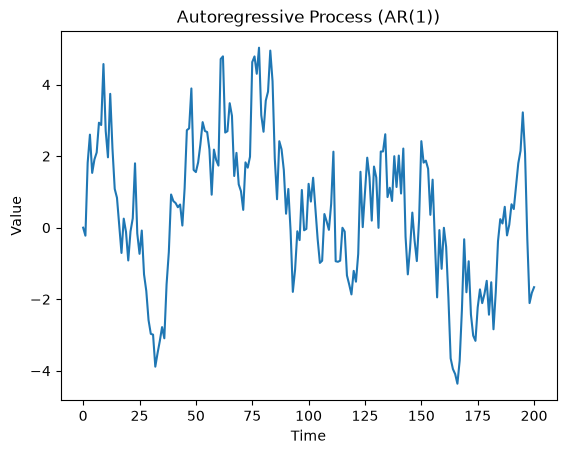

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

T = 200
alpha = 0.9
x = np.empty(T+1)
x[0] = 0

for t in range(T):
    x[t+1] = alpha * x[t] + np.random.standard_normal()

plt.plot(x)
plt.title('Autoregressive Process (AR(1))')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

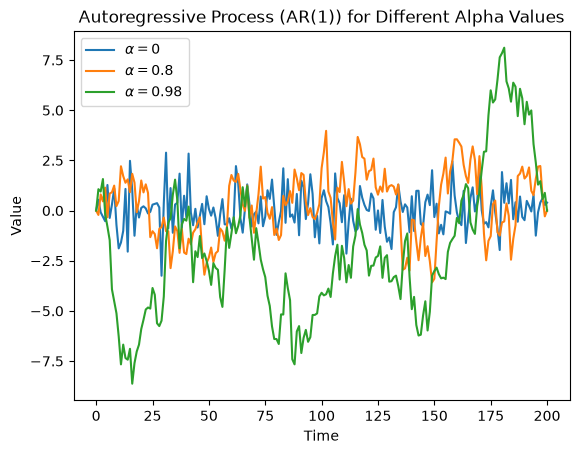

In [3]:
import numpy as np
import matplotlib.pyplot as plt

T = 200
x = np.empty(T+1)
x[0] = 0

for alpha in [0, 0.8, 0.98]:
    for t in range(T):
        x[t+1] = alpha * x[t] + np.random.standard_normal()
    plt.plot(x, label=f'$\\alpha={alpha}$')

plt.title('Autoregressive Process (AR(1)) for Different Alpha Values')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

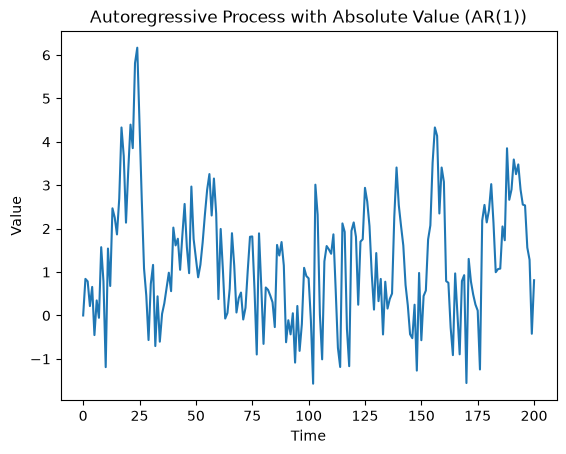

In [4]:
import numpy as np
import matplotlib.pyplot as plt

T = 200
alpha = 0.9
x = np.empty(T+1)
x[0] = 0

for t in range(T):
    x[t+1] = alpha * np.abs(x[t]) + np.random.standard_normal()

plt.plot(x)
plt.title('Autoregressive Process with Absolute Value (AR(1))')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

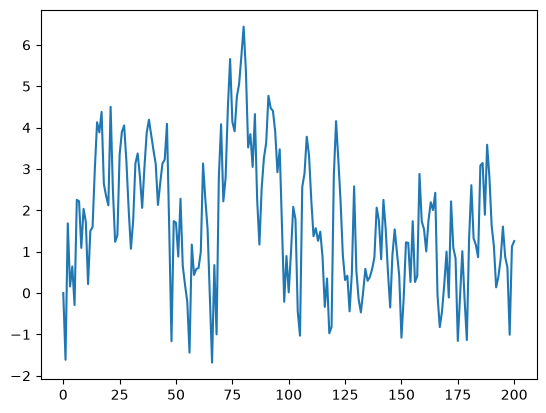

In [5]:
import numpy as np
import matplotlib.pyplot as plt

T = 200
alpha = 0.9
x = np.empty(T+1)
x[0] = 0

for t in range(T):
    if x[t] >= 0:
        x[t+1] = alpha * x[t] + np.random.standard_normal()
    else:
        x[t+1] = alpha * (-x[t]) + np.random.standard_normal()

plt.plot(x)
plt.show()

In [14]:
import numpy as np

N = 100000
x = np.empty(N+1)
y = np.empty(N+1)
x[0] = 0
y[0] = 0

for n in range(N):
    x[n] = np.random.uniform(-1, 1)
    y[n] = np.random.uniform(-1, 1)


'''
The summation of [-1,1]^2 is equal to 4, and the area of the unit circle is pi.
Then pi/4 is equal to the probability of the points falling inside the unit circle.
Therefore, pi/4 = (number of points inside the unit circle) / N holds 
'''
p = np.sum(x**2 + y**2 <= 1) / N * 4

print(f'pi approximation: {p}')


pi approximation: 3.13436


In [12]:
# Another solution

N = 100000

count = 0
for i in range(N):
    u,v = np.random.uniform(), np.random.uniform()
    d = np.sqrt((u - 0.5)**2 + (v - 0.5)**2)
    if d <= 0.5:
        count += 1

area_estimate = count / N

print(area_estimate * 4)

3.14248


### Exercise4.1 ~ 4.5

In [ ]:
# 4.1

def factorial(n):
    if n == 0:
        return 1
    else:
        return n * factorial(n-1)

factorial(4)

24

In [17]:
# another solution

def factorial(n):
    k = 1
    for i in range(n):
        k = k * (i + 1)
    return k

factorial(4)

24

In [ ]:
# 4.2

"""
二項分布は、n回の独立した試行において、各試行で成功する確率がpであるとき、成功する回数の分布である。
"""

import numpy as np

def binomial_rv(n, p):
    count = 0
    for i in range(n):
        U = np.random.uniform()
        if U < p:
            count = count + 1
    return count

binomial_rv(10, 0.5)
    

4

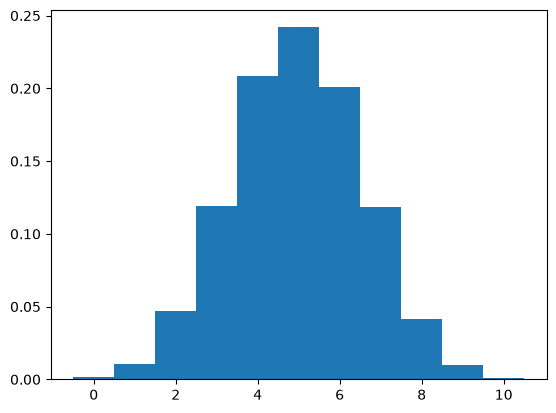

In [19]:
import matplotlib.pyplot as plt

plt.hist([binomial_rv(10, 0.5) for _ in range(10000)], bins=range(12), align='left', density=True)
plt.show()

In [ ]:
# 4.3 first function

import numpy as np

def draw(k):

    payoff = 0
    count = 0

    for i in range(10):
        U = np.random.uniform()
        count = count + 1 if U < 0.5 else 0   # elseで0にリセットすることで、連続する成功回数をカウントする
        print(f'count: {count}')

        if count == k:
            payoff = 1

    return payoff

draw(4)


count: 0
count: 0
count: 1
count: 2
count: 3
count: 4
count: 0
count: 0
count: 0
count: 0


1

In [ ]:
# 4.3 second function

import numpy as np

def draw_second(k):

    payoff = 0
    count = 0

    for i in range(10):
        U = np.random.uniform()
        count = count + 1 if U < 0.5 else count
        print(f'count: {count}')

        if count >= k:
            payoff = 1

    return payoff

draw_second(4)

count: 0
count: 1
count: 1
count: 1
count: 1
count: 2
count: 2
count: 3
count: 4
count: 5


1

In [28]:
# 4.4

import numpy as np

def Fibonacci(t):
    x = np.empty(t)
    x[0] = 0
    x[1] = 1
    for i in range(2, t):
        x[i] = x[i-1] + x[i-2]
    return x

print(Fibonacci(10))

[ 0.  1.  1.  2.  3.  5.  8. 13. 21. 34.]


In [ ]:
# another solution -- recursive function

def x(t):
    if t == 0:
        return 0
    if t == 1:
        return 1
    return x(t-1) + x(t-2)

print([x(i) for i in range(10)])

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]


In [29]:
# 4.5

def recursion_factorial(n):
    if n == 0:
        return 1
    else:
        return n * recursion_factorial(n-1)

print([recursion_factorial(i) for i in range(1, 10)])

[1, 2, 6, 24, 120, 720, 5040, 40320, 362880]
